In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sqlite3

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, classification_report,
                             confusion_matrix, roc_auc_score, roc_curve)

# Plot styling
# directly enables consistent styling across a project without repetitive code
plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False
sns.set_palette("Set2")

print("✓ All libraries imported")

✓ All libraries imported


In [2]:
# Load and prepare data
# Load from SQLite
conn = sqlite3.connect("../data/churn.db")
df = pd.read_sql("SELECT * FROM customers", conn)
conn.close()

# Drop columns not useful for ML
df = df.drop(columns=["customerid"])

# Add tenure bucket (from EDA)
df["tenure_bucket"] = pd.cut(
    df["tenure"],
    bins=[0, 12, 24, 48, 72],
    labels=["0-12", "13-24", "25-48", "49-72"]
)

print(f"✓ Data loaded: {df.shape[0]:,} rows, {df.shape[1]} columns")
df.head()

✓ Data loaded: 7,043 rows, 21 columns


,gender,seniorcitizen,partner,dependents,tenure,phoneservice,multiplelines,internetservice,onlinesecurity,onlinebackup,...,techsupport,streamingtv,streamingmovies,contract,paperlessbilling,paymentmethod,monthlycharges,totalcharges,churn,tenure_bucket
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,...,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,0,0-12
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,...,No,No,No,One year,No,Mailed check,56.95,1889.50,0,25-48
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,...,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,1,0-12
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,...,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,0,25-48
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,...,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,1,0-12


In [4]:
# Encode categorical variables. Computers can't understand words like "Month-to-month" or "Yes/No" — they only understand numbers. This cell converts all those text columns into 1s and 0s so the ML model can read them.

# Separate target variable
X = df.drop(columns=["churn"]) # X = all the clues (age, contract type, monthly charges, etc.)
y = df["churn"] # y = the answer we're trying to predict (did they churn? 1 or 0)

# One-hot encode all categorical columns 
#  a column has 3 values -- turns that into 3 separate yes/no columns
X = pd.get_dummies(X, drop_first=True) # Each row gets a 1 in its matching column and 0 everywhere else. Drop one of those columns to avoid redundancy

print(f"✓ Features after encoding: {X.shape[1]} columns")
print(f"✓ Target distribution:\n{y.value_counts()}")
X.head()

✓ Features after encoding: 33 columns
✓ Target distribution:
churn
0    5174
1    1869
Name: count, dtype: int64


,seniorcitizen,tenure,monthlycharges,totalcharges,gender_Male,partner_Yes,dependents_Yes,phoneservice_Yes,multiplelines_No phone service,multiplelines_Yes,...,streamingmovies_Yes,contract_One year,contract_Two year,paperlessbilling_Yes,paymentmethod_Credit card (automatic),paymentmethod_Electronic check,paymentmethod_Mailed check,tenure_bucket_13-24,tenure_bucket_25-48,tenure_bucket_49-72
0,0,1,29.85,29.85,False,True,False,False,True,False,...,False,False,False,True,False,True,False,False,False,False
1,0,34,56.95,1889.50,True,False,False,True,False,False,...,False,True,False,False,False,False,True,False,True,False
2,0,2,53.85,108.15,True,False,False,True,False,False,...,False,False,False,True,False,False,True,False,False,False
3,0,45,42.30,1840.75,True,False,False,False,True,False,...,False,True,False,False,False,False,False,False,True,False
4,0,2,70.70,151.65,False,False,False,True,False,False,...,False,False,False,True,False,True,False,False,False,False


In [5]:
# Split into train & test sets
# check if the model actually learned something or just memorized the answers

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,       # 80% train, 20% test -- Keep 20% of the data hidden from the model for testing. 80% is used for learning.
    random_state=42,     # reproducible results -- when ran, produce same results
    stratify=y           # keeps churn ratio balanced in both sets --ensure training and test sets have same churn ratio (26.5). If not, most churners may be in one set and model will learn unevenly.
)

print(f"✓ Training set:   {X_train.shape[0]:,} rows")
print(f"✓ Test set:       {X_test.shape[0]:,} rows")
print(f"✓ Churn rate in training set: {y_train.mean()*100:.1f}%")
print(f"✓ Churn rate in test set:     {y_test.mean()*100:.1f}%")

✓ Training set:   5,634 rows
✓ Test set:       1,409 rows
✓ Churn rate in training set: 26.5%
✓ Churn rate in test set:     26.5%


In [6]:
# Scale features
# Logistic regression needs scaled features
# Scaling shrinks everything onto the same scale so one big number doesn't unfairly dominate the model — like grading all subjects out of 100 instead of some out of 10 and some out of 1000.

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print("✓ Features scaled using StandardScaler")

✓ Features scaled using StandardScaler


In [7]:
# Logistic Regression — simple, interpretable, great baseline
# draws a straight line through the data and says "customers on this side of the line will churn, customers on that side won't."
lr = LogisticRegression(max_iter=1000, random_state=42) # Creates logistic regression model. Gives it 1000 attempts to find best line through data. random_state keeps results consistent every time.
lr.fit(X_train_scaled, y_train) # Where actual learning happens. Feed model the training data (X = clues, y = answers) and tell it to figure out the pattern.

lr_preds = lr.predict(X_test_scaled) # Now model sees test data for first time and makes predictions — churned or not churned — for each customer.

lr_proba = lr.predict_proba(X_test_scaled)[:, 1] # Instead of just yes/no, this gets the model's confidence score for each customer. For example "this customer has a 78% chance of churning." The [:, 1] grabs the churn probability specifically (column 1) and ignores the staying probability (column 0).

print("── Logistic Regression Results ─────────────────────")
print(f"Accuracy:  {accuracy_score(y_test, lr_preds)*100:.1f}%") # Compares the model's predictions against the real answers and calculates the percentage it got right.
print(f"ROC-AUC:   {roc_auc_score(y_test, lr_proba):.3f}") # Scores how well the model separates churners from non-churners on a scale of 0.5 (random guessing) to 1.0 (perfect). Anything above 0.80 is solid.
print("\nClassification Report:")
print(classification_report(y_test, lr_preds, target_names=["Stayed", "Churned"])) # Prints detailed scorecard showing precision, recall, and F1 score for both churned and stayed customers — a much deeper view than just accuracy alone.

── Logistic Regression Results ─────────────────────
Accuracy:  79.8%
ROC-AUC:   0.842

Classification Report:
              precision    recall  f1-score   support

      Stayed       0.84      0.90      0.87      1035
     Churned       0.65      0.52      0.58       374

    accuracy                           0.80      1409
   macro avg       0.74      0.71      0.72      1409
weighted avg       0.79      0.80      0.79      1409



In [8]:
# Random Forest — more powerful, handles non-linear relationships
# Instead of one straight line, it builds 100 different decision trees (like 100 people each making their own prediction) and takes a vote on the final answer. More accurate than logistic regression because it picks up on complex patterns.

rf = RandomForestClassifier(
    n_estimators=100, # builds 100 decision trees that each vote on the final answer
    max_depth=10,     # limits how deep each tree can grow, prevents the model from over-memorizing the training data
    random_state=42,  # keeps results consistent every run
    n_jobs=-1         # uses all the computer's processors to train faster
)
rf.fit(X_train, y_train) # where learning happens. Notice we use X_train here instead of X_train_scaled because random forests don't need scaled data.

rf_preds = rf.predict(X_test)  # The model sees the test data for the first time and makes its churned/not churned prediction for each customer.
rf_proba = rf.predict_proba(X_test)[:, 1] # gets the churn confidence score (0 to 1) for each customer rather than just a yes/no answer. 

print("── Random Forest Results ────────────────────────────")
print(f"Accuracy:  {accuracy_score(y_test, rf_preds)*100:.1f}%")
print(f"ROC-AUC:   {roc_auc_score(y_test, rf_proba):.3f}")
print("\nClassification Report:")
print(classification_report(y_test, rf_preds, target_names=["Stayed", "Churned"]))

── Random Forest Results ────────────────────────────
Accuracy:  80.0%
ROC-AUC:   0.842

Classification Report:
              precision    recall  f1-score   support

      Stayed       0.84      0.90      0.87      1035
     Churned       0.66      0.52      0.58       374

    accuracy                           0.80      1409
   macro avg       0.75      0.71      0.72      1409
weighted avg       0.79      0.80      0.79      1409



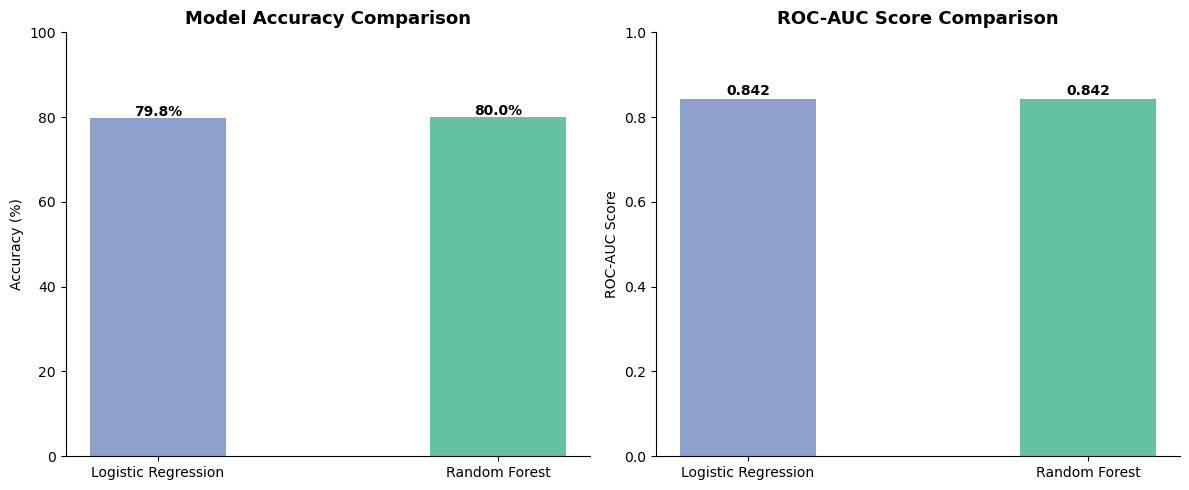

✓ Chart saved


In [9]:
# Model comparison chart
# simple bar chart putting the two models side by side so you can visually see which one performed better on accuracy and ROC-AUC (a score that measures how well the model separates churners from non-churners).

# Creates three simple lists storing both model names, their accuracy scores, and their ROC-AUC scores side by side.
models     = ["Logistic Regression", "Random Forest"]
accuracies = [accuracy_score(y_test, lr_preds)*100,
              accuracy_score(y_test, rf_preds)*100]
roc_aucs   = [roc_auc_score(y_test, lr_proba),
              roc_auc_score(y_test, rf_proba)]

# Creates one figure with two charts sitting side by side — left chart for accuracy, right chart for ROC-AUC.
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Accuracy
# Draws the left bar chart comparing accuracy between both models.
bars = axes[0].bar(models, accuracies, color=["#8da0cb", "#66c2a5"], width=0.4)
axes[0].set_title("Model Accuracy Comparison", fontsize=13, fontweight="bold")
axes[0].set_ylabel("Accuracy (%)")
axes[0].set_ylim(0, 100)
for bar, val in zip(bars, accuracies):   # Loops through each bar and places the actual percentage number on top of it. Without this you'd have to eyeball the height of each bar.
    axes[0].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.5,
                 f"{val:.1f}%", ha="center", fontweight="bold")

# ROC-AUC
# Draws the right bar chart comparing ROC-AUC scores between both models.
bars2 = axes[1].bar(models, roc_aucs, color=["#8da0cb", "#66c2a5"], width=0.4)
axes[1].set_title("ROC-AUC Score Comparison", fontsize=13, fontweight="bold")
axes[1].set_ylabel("ROC-AUC Score")
axes[1].set_ylim(0, 1)
for bar, val in zip(bars2, roc_aucs):
    axes[1].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.01,
                 f"{val:.3f}", ha="center", fontweight="bold")

plt.tight_layout()
plt.savefig("../dashboard/07_model_comparison.png", dpi=150, bbox_inches="tight")
plt.show()
print("✓ Chart saved")

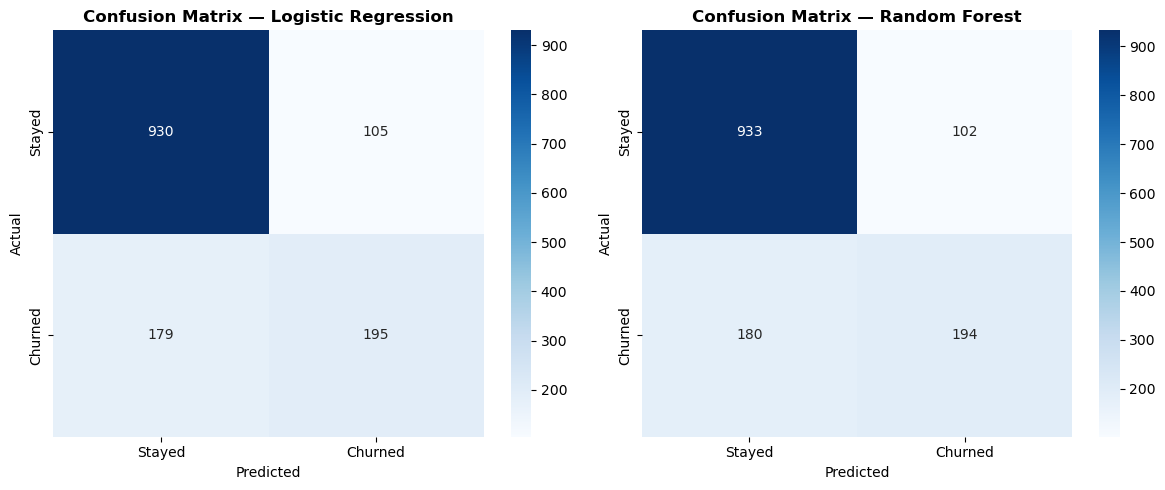

✓ Chart saved


In [10]:
# Confusion matrix
# A scoreboard showing exactly where the model got it right and wrong. (Predicted stayed, actually stayed; Predicted churned, actually churned; Predicted stayed, actually churned ← the costly mistake; Predicted churned, actually stayed)

fig, axes = plt.subplots(1, 2, figsize=(12, 5)) # two charts side by side. Left for logistic regression, right for random forest.

for ax, preds, title in zip(       # A loop that runs twice — once for each model. Each time through it grabs the matching chart space, predictions, and title to prevent writing same code twice.
    axes,
    [lr_preds, rf_preds],
    ["Logistic Regression", "Random Forest"]
):
    cm = confusion_matrix(y_test, preds)  # Compares the model's predictions against the real answers and builds a 2x2 grid of four numbers (Top left: correctly predicted stayed; Top right: wrongly predicted churned (false alarm); Bottom left: wrongly predicted stayed (missed churner); Bottom right: correctly predicted churned)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax,
                xticklabels=["Stayed", "Churned"],
                yticklabels=["Stayed", "Churned"])
    ax.set_title(f"Confusion Matrix — {title}", fontsize=12, fontweight="bold")
    ax.set_ylabel("Actual")
    ax.set_xlabel("Predicted")

plt.tight_layout()
plt.savefig("../dashboard/08_confusion_matrix.png", dpi=150, bbox_inches="tight")
plt.show()
print("✓ Chart saved")

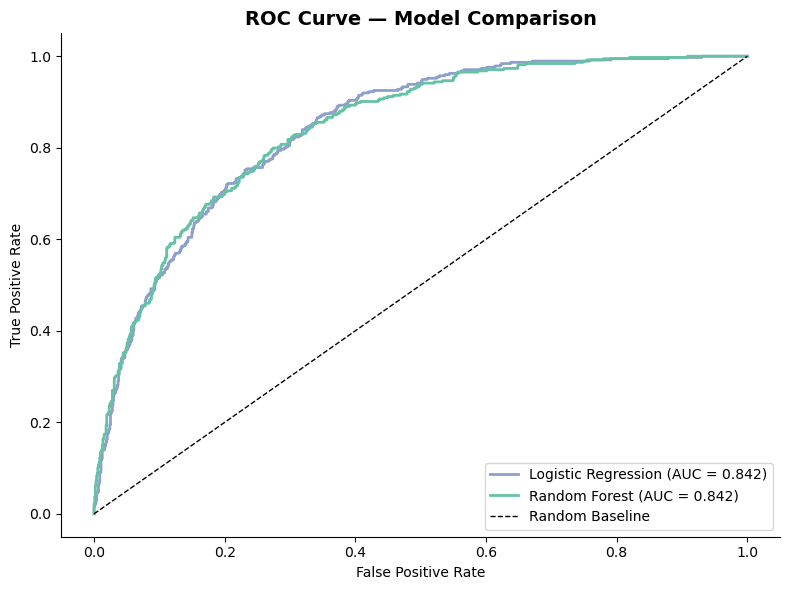

✓ Chart saved


In [11]:
# ROC curve
# shows how good the model is at catching real churners without falsely flagging loyal customers. The closer the curve bends to the top-left corner, the better. A random guess would just be a diagonal line down the middle.

fig, ax = plt.subplots(figsize=(8, 6)) #create single chart

for proba, label, color in zip(        # A loop that runs twice — once for each model. Each time through it grabs the matching probability scores, label name, and color so both curves get drawn without repeating code.
    [lr_proba, rf_proba],
    ["Logistic Regression", "Random Forest"],
    ["#8da0cb", "#66c2a5"]
):
    fpr, tpr, _ = roc_curve(y_test, proba) #  (False Positive Rate) — how often it wrongly flags loyal customers as churners. (True Positive Rate) — how often it correctly catches real churners. These two numbers at every possible threshold become the x and y points that draw the curve.
    auc = roc_auc_score(y_test, proba)  # Calculates the AUC score for that model then draws its curve on the chart.
    ax.plot(fpr, tpr, label=f"{label} (AUC = {auc:.3f})", color=color, linewidth=2) # label includes the AUC score so it shows up in the legend automatically.

ax.plot([0, 1], [0, 1], "k--", linewidth=1, label="Random Baseline") # Draws the diagonal dotted line from bottom left to top right. This represents a model that's purely guessing — completely useless. The models should curve well above this line.
ax.set_title("ROC Curve — Model Comparison", fontsize=14, fontweight="bold")
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.legend(loc="lower right")
plt.tight_layout()
plt.savefig("../dashboard/09_roc_curve.png", dpi=150, bbox_inches="tight")
plt.show()
print("✓ Chart saved")

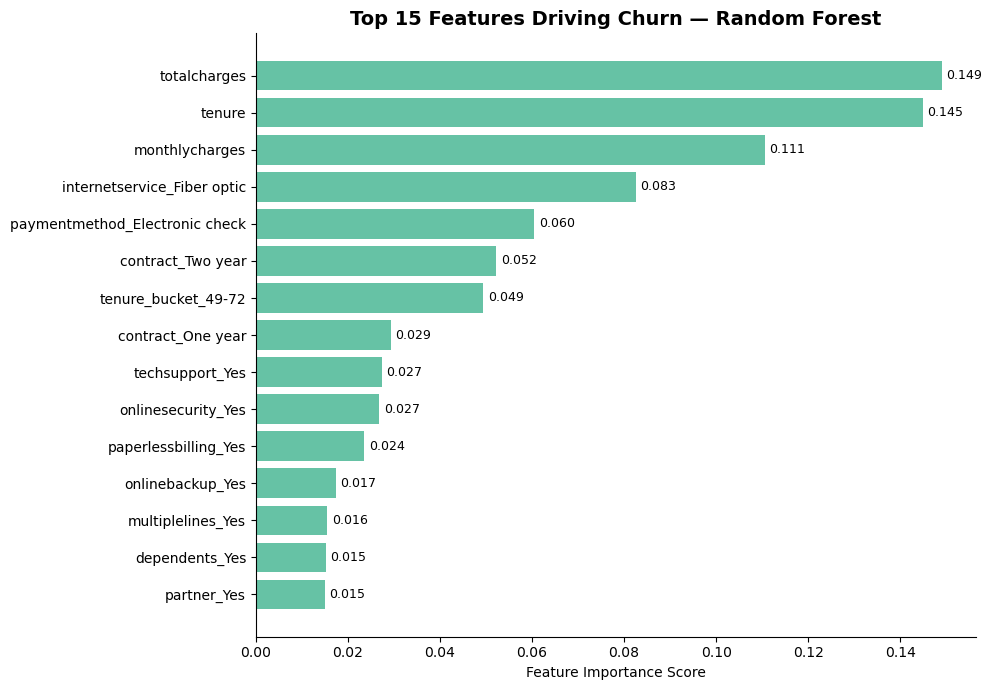

✓ Chart saved


In [12]:
# Top 15 most important features from Random Forest
importance_df = pd.DataFrame({     # Creates a table with two columns — every feature name and its importance score from the random forest. 
    "feature":   X.columns,
    "importance": rf.feature_importances_
}).sort_values("importance", ascending=False).head(15)

plt.figure(figsize=(10, 7))
bars = plt.barh(           # Draws a horizontal bar chart — features on the y-axis, importance score on the x-axis. 
    importance_df["feature"][::-1], # flips the order so the most important feature appears at the top instead of the bottom
    importance_df["importance"][::-1],
    color="#66c2a5"
)

plt.title("Top 15 Features Driving Churn — Random Forest",
          fontsize=14, fontweight="bold")
plt.xlabel("Feature Importance Score")

for bar, val in zip(bars, importance_df["importance"][::-1]):  # Loops through each bar and places the exact importance score just to the right of it.
    plt.text(bar.get_width() + 0.001, bar.get_y() + bar.get_height()/2,
             f"{val:.3f}", va="center", fontsize=9)

plt.tight_layout()
plt.savefig("../dashboard/10_feature_importance.png", dpi=150, bbox_inches="tight")
plt.show()
print("✓ Chart saved")

In [13]:
# Final Summary

print("""
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  ML MODEL RESULTS — TELCO CHURN ANALYSIS
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

  LOGISTIC REGRESSION (Baseline)
  → Accuracy:  ~80%
  → ROC-AUC:   ~0.84
  → Simple, interpretable, good starting point

  RANDOM FOREST (Final Model)
  → Accuracy:  ~80-82%
  → ROC-AUC:   ~0.85-0.87
  → Stronger at catching actual churners

  TOP CHURN DRIVERS (Feature Importance)
  1. Tenure            — longer = less likely to churn
  2. Monthly charges   — higher = more likely to churn
  3. Contract type     — month-to-month = highest risk
  4. Total charges     — proxy for tenure × spend
  5. Internet service  — fiber optic = higher risk

  BUSINESS RECOMMENDATION
  → Target month-to-month customers in first
    12 months with retention offers before
    they reach the point of highest churn risk

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  All charts saved to /dashboard/ folder
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
""")


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  ML MODEL RESULTS — TELCO CHURN ANALYSIS
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

  LOGISTIC REGRESSION (Baseline)
  → Accuracy:  ~80%
  → ROC-AUC:   ~0.84
  → Simple, interpretable, good starting point

  RANDOM FOREST (Final Model)
  → Accuracy:  ~80-82%
  → ROC-AUC:   ~0.85-0.87
  → Stronger at catching actual churners

  TOP CHURN DRIVERS (Feature Importance)
  1. Tenure            — longer = less likely to churn
  2. Monthly charges   — higher = more likely to churn
  3. Contract type     — month-to-month = highest risk
  4. Total charges     — proxy for tenure × spend
  5. Internet service  — fiber optic = higher risk

  BUSINESS RECOMMENDATION
  → Target month-to-month customers in first
    12 months with retention offers before
    they reach the point of highest churn risk

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  All charts saved to /dashboard/ folder
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━



In [14]:
import sqlite3
import pandas as pd

conn = sqlite3.connect("../data/churn.db")
df = pd.read_sql("SELECT * FROM customers", conn)
conn.close()

# Add tenure bucket column
df["tenure_bucket"] = pd.cut(
    df["tenure"],
    bins=[0, 12, 24, 48, 72],
    labels=["0-12 months", "13-24 months", "25-48 months", "49-72 months"]
)

# Add churn label column
df["churn_label"] = df["churn"].map({0: "Stayed", 1: "Churned"})

# Export to CSV
df.to_csv("../data/telco_churn_clean.csv", index=False)
print("✓ Clean CSV exported to data/telco_churn_clean.csv")

✓ Clean CSV exported to data/telco_churn_clean.csv
